In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'bilateral-m1-pcca', 'tools'))
# Simpler if you run the notebook from the repo root:
sys.path.insert(0, 'tools')


In [2]:
import scipy.io
import numpy as np
from load_session import inspect_session, load_session
from trial_epoching import get_trial_start_indices, get_touch_start_indices, get_trial_outcomes, compute_derived    
from plotting_fncs import plot_trial_variable

import matplotlib.pyplot as plt
%matplotlib widget


In [3]:
# inspect_session('data/P1.mat')

In [4]:
session_data = load_session('data/U2.mat')
derived = compute_derived(session_data)

## U7, U8 problem
## U1 only has 17 neurons in LH




In [5]:
### Stimulus and outcome information

print(f' All Unique stimuli: {set(derived["trial_stimuli"])}')
print(f' Rewarded stimuli: {set([derived["trial_stimuli"][i] for i, o in enumerate(derived["trial_outcomes"]) if o in ["hit", "miss"]])}')
print(f' Unrewarded stimuli: {set([derived["trial_stimuli"][i] for i, o in enumerate(derived["trial_outcomes"]) if o in ["false_alarm", "correct_rej"]])}')
print(f' Total hit trials: {sum([1 for o in derived["trial_outcomes"] if o == "hit"])}')
print(f' Total miss trials: {sum([1 for o in derived["trial_outcomes"] if o == "miss"])}')
print(f' Total false alarm trials: {sum([1 for o in derived["trial_outcomes"] if o == "false_alarm"])}')
print(f' Total correct rejection trials: {sum([1 for o in derived["trial_outcomes"] if o == "correct_rej"])}')

 All Unique stimuli: {'rightD+leftC', 'rightC+leftC', 'rightC+leftD', 'leftC', 'rightC', 'leftD', 'rightD', 'rightD+leftD'}
 Rewarded stimuli: {'rightC'}
 Unrewarded stimuli: {'rightD+leftC', 'rightC+leftC', 'rightC+leftD', 'leftC', 'leftD', 'rightD', 'rightD+leftD'}
 Total hit trials: 113
 Total miss trials: 4
 Total false alarm trials: 12
 Total correct rejection trials: 313


In [6]:
### Neuronal data information

print(f'LH neurons: {session_data["n_lh"]}, RH neurons: {session_data["n_rh"]}, Total neurons: {session_data["n_lh"] + session_data["n_rh"]}')

rs = np.sum(session_data['fsrs'] == 1)
fs = np.sum(session_data['fsrs'] == -1)
un = np.sum(session_data['fsrs'] == 0)

print(f"RS: {rs}, FS: {fs}, UN: {un}")

for hemi, mask in [('LH', session_data['loc_lh_mask']), ('RH', session_data['loc_rh_mask'])]:
    fsrs = session_data['fsrs'][mask]
    print(f"{hemi}  RS: {(fsrs==1).sum()}  FS: {(fsrs==-1).sum()}  UN: {(fsrs==0).sum()}")


LH neurons: 100, RH neurons: 98, Total neurons: 198
RS: 184, FS: 6, UN: 8
LH  RS: 97  FS: 1  UN: 2
RH  RS: 87  FS: 5  UN: 6


Hit trials : 113
Touch latency — mean: 0.662 s  median: 0.660 s
Lick latency  — mean: 1.050 s  median: 1.054 s


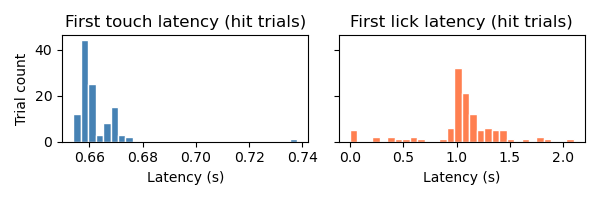

In [7]:
from load_session import TIME_STEP

# ── Reference point: swap between trial start and stimulus onset ──────────
reference_frames = derived['trial_start_indices'].astype(float)   # trial start
# reference_frames = derived['stimulus_onset_frame']              # stimulus onset

# ── Hit trials only ───────────────────────────────────────────────────────
hit_mask = np.array([o == 'hit' for o in derived['trial_outcomes']])

# ── Latencies (seconds) ───────────────────────────────────────────────────
touch_latency_s = (derived['first_touch_frame'][hit_mask] - reference_frames[hit_mask]) * TIME_STEP
lick_latency_s  = (derived['first_lick_frame'][hit_mask]  - reference_frames[hit_mask]) * TIME_STEP

print(f"Hit trials : {hit_mask.sum()}")
print(f"Touch latency — mean: {np.nanmean(touch_latency_s):.3f} s  median: {np.nanmedian(touch_latency_s):.3f} s")
print(f"Lick latency  — mean: {np.nanmean(lick_latency_s):.3f} s  median: {np.nanmedian(lick_latency_s):.3f} s")

fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)

axes[0].hist(touch_latency_s[~np.isnan(touch_latency_s)], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Latency (s)')
axes[0].set_ylabel('Trial count')
axes[0].set_title('First touch latency (hit trials)')

axes[1].hist(lick_latency_s[~np.isnan(lick_latency_s)], bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Latency (s)')
axes[1].set_title('First lick latency (hit trials)')

plt.tight_layout()
plt.show()


In [8]:


# valid_vars = ['piston_frames', 'touch_frames', 'whisker_angle', 'curvature',
#               'phase', 'run_speed', 'hits', 'misses', 'false_alarms',
#               'correct_rejs', 'licks']
# for var_name in valid_vars:
#     if var_name in ['hits', 'misses', 'false_alarms', 'correct_rejs', 'licks']:
#         plot_trial_variable(session_data, session_data['trial_start_indices'], var_name=var_name, trial_idx=1, ylim=(-0.1, 1.1))
#     else:
#         plot_trial_variable(session_data, session_data['trial_start_indices'], var_name=var_name, trial_idx=1)



In [9]:
from load_session import TIME_STEP

def get_neuron_mask(session_data, hemisphere='LH', fsrs=None, min_rate_hz=None,
                    time_step=TIME_STEP):
    loc_mask = session_data['loc_lh_mask'] if hemisphere == 'LH' else session_data['loc_rh_mask']
    mask = loc_mask.copy()

    if fsrs is not None:
        mask &= np.isin(session_data['fsrs'], fsrs)

    if min_rate_hz is not None:
        hemi_spikes = session_data['spikes'][:, loc_mask]
        mean_rate   = hemi_spikes.mean(axis=0) / time_step
        rate_filter = np.zeros(len(loc_mask), dtype=bool)
        rate_filter[loc_mask] = mean_rate >= min_rate_hz
        mask &= rate_filter

    return mask[loc_mask]  # scoped to this hemisphere's neurons


def build_spike_count_matrices(session_data, trial_indices, reference_frames,
                                window=(0.0, 1.0), time_step=TIME_STEP,
                                lh_neuron_mask=None, rh_neuron_mask=None):
    win_start = int(round(window[0] / time_step))
    win_end   = int(round(window[1] / time_step))
    n_frames  = session_data['spikes'].shape[0]
    n         = len(trial_indices)

    n_lh = lh_neuron_mask.sum() if lh_neuron_mask is not None else session_data['n_lh']
    n_rh = rh_neuron_mask.sum() if rh_neuron_mask is not None else session_data['n_rh']

    lh_matrix = np.zeros((n, n_lh), dtype=float)
    rh_matrix = np.zeros((n, n_rh), dtype=float)

    for row, trial_idx in enumerate(trial_indices):
        ref   = int(reference_frames[trial_idx])
        start = max(ref + win_start, 0)
        end   = min(ref + win_end,   n_frames)

        lh_spikes = session_data['spikes'][start:end][:, session_data['loc_lh_mask']]
        rh_spikes = session_data['spikes'][start:end][:, session_data['loc_rh_mask']]

        if lh_neuron_mask is not None:
            lh_spikes = lh_spikes[:, lh_neuron_mask]
        if rh_neuron_mask is not None:
            rh_spikes = rh_spikes[:, rh_neuron_mask]

        lh_matrix[row] = lh_spikes.sum(axis=0)
        rh_matrix[row] = rh_spikes.sum(axis=0)

    return lh_matrix, rh_matrix


In [10]:
hit_fast_lick_mask = hit_mask.copy()
hit_fast_lick_mask[hit_mask] = lick_latency_s > 1.0

# Trial indices (into derived arrays) that pass the filter
filtered_trial_indices = np.where(hit_fast_lick_mask)[0]

print(f"Hit trials with lick latency > 1.0 s: {len(filtered_trial_indices)}")

lh_neuron_mask = get_neuron_mask(session_data, hemisphere='LH', fsrs=[1, -1], min_rate_hz=0.5)
rh_neuron_mask = get_neuron_mask(session_data, hemisphere='RH', fsrs=[1, -1], min_rate_hz=0.5)

lh_matrix, rh_matrix = build_spike_count_matrices(
    session_data,
    trial_indices    = filtered_trial_indices,
    reference_frames = derived['trial_start_indices'],  # or derived['stimulus_onset_frame']
    window           = (0.0, 1.0),
    lh_neuron_mask   = lh_neuron_mask,
    rh_neuron_mask   = rh_neuron_mask,
)

print(f"LH: {lh_neuron_mask.sum()} / {session_data['n_lh']} neurons kept")
print(f"RH: {rh_neuron_mask.sum()} / {session_data['n_rh']} neurons kept")
print(f"LH matrix: {lh_matrix.shape},  RH matrix: {rh_matrix.shape}")


Hit trials with lick latency > 1.0 s: 89
LH: 98 / 100 neurons kept
RH: 92 / 98 neurons kept
LH matrix: (89, 98),  RH matrix: (89, 92)
